# Footfall: Data Cleaning, Exploratory Data Analysis and Distribution

This notebook aggregates, cleans and prepares the footfall data for analysis.

In [1]:
pip install matplotlib geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

## Step 1: Cleaning and Aggregating Footfall Data

The daily footfall 2019-2024 datasets for the different Bradford locations are loaded, concatenated and cleaned.

In [3]:
import glob
import os

#Folder with containing all areas
folder_path = r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Footfall data 2019-2024"

#Find all CSVs in all subfolders
area_folders = glob.glob(os.path.join(folder_path, '*'))

#Define file names
custom_name = ['footfall']

#Dict to store combined dataframes by file type
combined = {name: pd.DataFrame() for name in custom_name}

for area_path in area_folders:
    #Get area name
    area_name = os.path.basename(area_path)
    
    csv_files = sorted(glob.glob(os.path.join(area_path, '*.csv')))
    
    #Loop over CSVs and assign new name
    for i, file in enumerate (csv_files):
        df = pd.read_csv(file, encoding='cp1252')
        
        #Add area column
        df['region'] = area_name
        
        #Get the new names
        new_name = custom_name[i]
        
        #Concatenate into 
        combined[new_name] = pd.concat([combined[new_name], df], ignore_index=True)

In [4]:
#Extract into dataframe
df_footfall = combined['footfall']

In [5]:
df_footfall.head()

,area,Interval,Date,Total Footfall,Average Footfall,Total Visiting,Average Visiting,Total Passing through,Average Passing through,Event took place,region,Unnamed: 9,Event Name,Event name
0,"Balancing Art - Coates Street, Bradford Foyer,...",dayOfWeek,01/01/2019,844612.85,2307.69,408949.1487,1117.349636,435663.7013,1190.340364,NaN,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN,NaN,NaN
1,"Balancing Art - Coates Street, Bradford Foyer,...",dayOfWeek,07/01/2019,771831.49,2108.83,373709.4821,1021.064542,398122.0079,1087.765458,NaN,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN,NaN,NaN
2,"Balancing Art - Coates Street, Bradford Foyer,...",dayOfWeek,14/01/2019,955770.21,2611.39,462769.9113,1264.396720,493000.2987,1346.993280,NaN,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN,NaN,NaN
3,"Balancing Art - Coates Street, Bradford Foyer,...",dayOfWeek,21/01/2019,853455.73,2331.85,413230.7414,1129.047554,440224.9886,1202.802446,NaN,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN,NaN,NaN
4,"Balancing Art - Coates Street, Bradford Foyer,...",dayOfWeek,28/01/2019,839562.82,2293.89,406503.9982,1110.667879,433058.8218,1183.222121,NaN,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN,NaN,NaN


In [6]:
df_footfall['Event took place'].value_counts()

Event took place
YES    2938
Name: count, dtype: int64

In [7]:
#Only keep columns interested in
df_footfall = df_footfall[['area', 'Interval', 'Date', 'Total Footfall']]
df_footfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38714 entries, 0 to 38713
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area            38714 non-null  object 
 1   Interval        38714 non-null  object 
 2   Date            38714 non-null  object 
 3   Total Footfall  38714 non-null  float64
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [8]:
df_footfall['Interval'].unique()

array(['dayOfWeek', 'daily', 'weekly', 'monthly'], dtype=object)

In [9]:
#Keep only the daily intervals
df_footfall = df_footfall[df_footfall['Interval'] == 'daily']

#Drop the interval column as the dataset now only contains daily data
df_footfall = df_footfall.drop(columns=['Interval'])

In [10]:
df_footfall['Date'] = pd.to_datetime(df_footfall['Date'], format='mixed', dayfirst= True)
df_footfall = df_footfall.rename(columns={'Date':'datestamp'})

In [11]:
#Rename total footfall column
df_footfall = df_footfall.rename(columns={'Total Footfall': 'estimated_actual_footfall'})

In [12]:
#Check the date range for each area
data_range_per_area = (
    df_footfall
    .groupby('area')['datestamp']
    .agg(min_date='min', max_date='max')
    .reset_index()
)

print(data_range_per_area)

                                                 area   min_date   max_date
0                                BD WALL - Wayfinders 2019-01-01 2026-01-17
1                      BD WALLS: Come on in my friend 2019-01-10 2025-01-01
2                               BD Walls - The Portal 2019-01-07 2024-12-09
3                     BD Walls : Serving the district 2019-01-07 2024-12-30
4                                      BD Walls Roots 2019-01-11 2024-10-01
5                                             Baildon 2019-01-07 2024-11-12
6   Balancing Art - Coates Street, Bradford Foyer,... 2019-02-11 2024-01-27
7                                            Bradford 2019-01-01 2026-01-04
8                              Bradford - City Centre 2019-01-07 2024-12-23
9                                        Bradford BID 2019-01-01 2026-01-04
10                               Draley Street Market 2019-01-07 2024-12-17
11                                        Lister Park 2019-01-07 2024-12-23
12          

In [13]:
#Check all areas in the data
df_footfall['area'].unique()

array(['Balancing Art - Coates Street, Bradford Foyer, Coates TER, Wootton Street',
       'BD WALLS: Come on in my friend', 'Roundwood Avenue',
       'BD Walls Roots', 'BD Walls : Serving the district',
       'BD Walls - The Portal', 'BD WALL - Wayfinders', 'Bradford',
       'Bradford BID', 'Bradford - City Centre', 'Draley Street Market',
       'Lister Park', 'Baildon', 'WILD UPLANDS'], dtype=object)

The data for 2025 is missing in certain areas, thus datasets containing this needs to be integrated.

In [14]:
import glob
import os

#Folder with containing all areas
folder_path = r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Footfall data 2025"

#Find all CSVs in all subfolders
area_folders = glob.glob(os.path.join(folder_path, '*'))

#Define file names
custom_name = ['footfall_2025']

#Dict to store combined dataframes by file type
combined = {name: pd.DataFrame() for name in custom_name}

for area_path in area_folders:
    #Get area name
    area_name = os.path.basename(area_path)
    
    csv_files = sorted(glob.glob(os.path.join(area_path, '*.csv')))
    
    #Loop over CSVs and assign new name
    for i, file in enumerate (csv_files):
        df = pd.read_csv(file, encoding='cp1252')
        
        #Add area column
        df['region'] = area_name
        
        #Get the new names
        new_name = custom_name[i]
        
        #Concatenate into 
        combined[new_name] = pd.concat([combined[new_name], df], ignore_index=True)

In [15]:
#Extract dataframe
F_2025 = combined['footfall_2025']

#Only keep columns interested in
F_2025 = F_2025[['area', 'Interval', 'Date', 'Total Footfall']]

#Keep only the daily intervals
F_2025 = F_2025[F_2025['Interval'] == 'daily']

#Drop the interval column as the dataset now only contains daily data
F_2025 = F_2025.drop(columns=['Interval'])

#Convert date column to datetime
F_2025['Date'] = pd.to_datetime(F_2025['Date'], format='mixed', dayfirst= True)
F_2025 = F_2025.rename(columns={'Date':'datestamp'})

#Rename total footfall column
F_2025 = F_2025.rename(columns={'Total Footfall': 'estimated_actual_footfall'})


#Check
F_2025.head()

,area,datestamp,estimated_actual_footfall
7,Bradford - Penistone Hill,2019-01-04,2056.59
8,Bradford - Penistone Hill,2019-01-05,4987.24
9,Bradford - Penistone Hill,2019-01-07,2493.62
10,Bradford - Penistone Hill,2019-01-11,2056.59
11,Bradford - Penistone Hill,2019-01-12,4987.24


In [16]:
#Check date ranges for each area
data_range_per_area = (
    F_2025
    .groupby('area')['datestamp']
    .agg(min_date='min', max_date='max')
    .reset_index()
)
print(data_range_per_area)

                                                 area   min_date   max_date
0       BD Walls : Root 1 Coates St, Bradford BD5 7DL 2024-12-25 2025-12-23
1                                       BD Walls RAVO 2024-12-28 2026-01-27
2             BD walls : Come on in my friend BD5 3PX 2024-12-25 2026-01-26
3                         BD walls the portal BD1 CBH 2024-12-25 2026-01-27
4   BD walls: Serving the district Morrisons, Brad... 2024-12-25 2026-01-27
5                                            Bradford 2024-12-25 2025-12-26
6                           Bradford - Penistone Hill 2019-01-04 2026-01-15
7                                Bradford city centre 2024-12-25 2026-01-27
8                              Darley's street market 2024-12-25 2026-01-27
9                                         Lister Park 2024-12-25 2026-01-27
10                    Painting the sky - Roberts part 2024-12-25 2026-01-25


In [17]:
F_2025['area'].unique()

array(['Bradford - Penistone Hill', 'Bradford',
       'BD walls : Come on in my friend BD5 3PX', 'BD Walls RAVO',
       'BD Walls : Root 1 Coates St, Bradford BD5 7DL',
       'BD walls: Serving the district Morrisons, Bradford Road, Idle BD10',
       'BD walls the portal BD1 CBH', 'Bradford city centre',
       "Darley's street market", 'Lister Park',
       'Painting the sky - Roberts part'], dtype=object)

In [18]:
df_footfall['area'].unique()

array(['Balancing Art - Coates Street, Bradford Foyer, Coates TER, Wootton Street',
       'BD WALLS: Come on in my friend', 'Roundwood Avenue',
       'BD Walls Roots', 'BD Walls : Serving the district',
       'BD Walls - The Portal', 'BD WALL - Wayfinders', 'Bradford',
       'Bradford BID', 'Bradford - City Centre', 'Draley Street Market',
       'Lister Park', 'Baildon', 'WILD UPLANDS'], dtype=object)

In [19]:
#Rename some of the area names as they don't match between the 2019-2024 and the 2025 datasets
F_2025['area'] = F_2025['area'].replace('Bradford', 'Balancing Art - Coates Street, Bradford Foyer, Coates TER, Wootton Street')
F_2025['area'] = F_2025['area'].replace('BD Walls RAVO', 'Roundwood Avenue')
F_2025['area'] = F_2025['area'].replace('BD walls: Serving the district Morrisons, Bradford Road, Idle BD10', 'BD Walls : Serving the district')
F_2025['area'] = F_2025['area'].replace('BD walls the portal BD1 CBH', 'BD Walls - The Portal')
F_2025['area'] = F_2025['area'].replace('Bradford city centre', 'Bradford - City Centre')
F_2025['area'] = F_2025['area'].replace("Darley's street market", 'Draley Street Market')


df_footfall['area'] = df_footfall['area'].replace('Bradford', 'Bradford BID')
df_footfall['area'] = df_footfall['area'].replace('WILD UPLANDS', 'Bradford - Penistone Hill')
df_footfall['area'] = df_footfall['area'].replace('BD WALLS: Come on in my friend', 'BD walls : Come on in my friend BD5 3PX')
df_footfall['area'] = df_footfall['area'].replace('BD Walls Roots', 'BD Walls : Root 1 Coates St, Bradford BD5 7DL')
df_footfall['area'] = df_footfall['area'].replace('Baildon', 'Painting the sky - Roberts part')

In [20]:
#Load footfall data for the 'Bradford MetOffice' aka district area
footfall_Met = pd.read_csv(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\footfall-MetOffice.csv")
footfall_Met.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2470 entries, 0 to 2469
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   datestamp                          2470 non-null   object 
 1   centre_name                        2470 non-null   object 
 2   purchasing_power_quantile          2470 non-null   int64  
 3   estimated_actual_footfall          2306 non-null   float64
 4   estimated_actual_footfall_rolling  2470 non-null   int64  
 5   indexed_signal                     0 non-null      float64
 6   indexed_signal_rolling             0 non-null      float64
 7   source                             2470 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 154.5+ KB


In [21]:
#Prepare the footfall for Bradford MetOffice area
footfall_Met = footfall_Met.drop(columns=['purchasing_power_quantile', 'indexed_signal', 'indexed_signal_rolling', 'source', 'estimated_actual_footfall_rolling'])
footfall_Met = footfall_Met.rename(columns={'centre_name': 'area'})
footfall_Met.head()

,datestamp,area,estimated_actual_footfall
0,2019-01-01,Met Office - Bradford,530996.0
1,2019-01-02,Met Office - Bradford,568621.0
2,2019-01-03,Met Office - Bradford,606939.0
3,2019-01-04,Met Office - Bradford,508695.0
4,2019-01-05,Met Office - Bradford,468546.0


In [22]:
#Add the bradford district footfall (MetOffice) and 2025 datasets
#Concatenate the now 3 datasets together (have the same columns)
footfall_mix = pd.concat([df_footfall, footfall_Met, F_2025], axis=0)
#Reset index
footfall_mix = footfall_mix.reset_index(drop= True)

#Convert datestamp to datetime
footfall_mix['datestamp'] = pd.to_datetime(footfall_mix['datestamp'])
footfall_mix.head()

,area,datestamp,estimated_actual_footfall
0,"Balancing Art - Coates Street, Bradford Foyer,...",2019-02-11,2272.41
1,"Balancing Art - Coates Street, Bradford Foyer,...",2019-02-18,2272.41
2,"Balancing Art - Coates Street, Bradford Foyer,...",2019-02-25,2272.41
3,"Balancing Art - Coates Street, Bradford Foyer,...",2019-02-27,2272.41
4,"Balancing Art - Coates Street, Bradford Foyer,...",2019-03-01,18179.26


In [23]:
#Rename all areas again for clarity and consistency
footfall_mix['area'] = footfall_mix['area'].replace('Met Office - Bradford', 'Bradford - Local Authority')
footfall_mix['area'] = footfall_mix['area'].replace('Bradford BID', 'Bradford - BID')
footfall_mix['area'] = footfall_mix['area'].replace('Lister Park', 'Bradford - Lister Park')
footfall_mix['area'] = footfall_mix['area'].replace('BD WALL - Wayfinders', 'BD Walls : Wayfinders')
footfall_mix['area'] = footfall_mix['area'].replace('BD Walls - The Portal', 'BD Walls : The Portal')
footfall_mix['area'] = footfall_mix['area'].replace('BD walls : Come on in my friend BD5 3PX', 'BD Walls : Come on in my friend')
footfall_mix['area'] = footfall_mix['area'].replace('BD Walls : Root 1 Coates St, Bradford BD5 7DL', 'BD Walls : Roots')
footfall_mix['area'] = footfall_mix['area'].replace('Roundwood Avenue', 'BD Walls: RAVO')
footfall_mix['area'] = footfall_mix['area'].replace('Draley Street Market', 'Darley Street Market')
footfall_mix['area'] = footfall_mix['area'].replace('Painting the sky - Roberts part', 'Bradford - Roberts Park')

In [24]:
footfall_mix['area'].value_counts()

area
Bradford - BID                                                               5122
Bradford - Penistone Hill                                                    3342
Bradford - City Centre                                                       2960
Bradford - Lister Park                                                       2960
BD Walls : Serving the district                                              2956
Darley Street Market                                                         2919
BD Walls : Come on in my friend                                              2910
BD Walls : The Portal                                                        2864
Bradford - Roberts Park                                                      2806
BD Walls : Wayfinders                                                        2574
BD Walls : Roots                                                             2515
Bradford - Local Authority                                                   2470
BD Walls: R

In [25]:
#Check for 0s
(footfall_mix['estimated_actual_footfall'] == 0).sum()


np.int64(0)

In [26]:
#Check for duplicates
print(footfall_mix.duplicated().sum())

#Take the average of duplicates per area per date
keys = ['datestamp', 'area']
footfall_mix = footfall_mix.groupby(keys).mean().reset_index()

#Check for duplicates again
print(footfall_mix.duplicated().sum())

39
0


In [27]:
#Check for NAs
print(footfall_mix['estimated_actual_footfall'].isna().value_counts())

#Drop missing data in 'estimated_actual_footfall'
footfall_mix = footfall_mix.dropna(subset=['estimated_actual_footfall'])
#Check again
print(footfall_mix['estimated_actual_footfall'].isna().value_counts())

estimated_actual_footfall
False    32119
True       164
Name: count, dtype: int64
estimated_actual_footfall
False    32119
Name: count, dtype: int64


In [28]:
#Remove 2026 data
footfall_mix = footfall_mix[(footfall_mix['datestamp'].dt.year) != 2026]

In [29]:
#Check date ranges per area again
data_range_per_area = (
    footfall_mix
    .groupby('area')['datestamp']
    .agg(min_date='min', max_date='max')
    .reset_index()
)
print(data_range_per_area)

                                                 area   min_date   max_date
0                     BD Walls : Come on in my friend 2019-01-10 2025-12-31
1                                    BD Walls : Roots 2019-01-11 2025-12-23
2                     BD Walls : Serving the district 2019-01-07 2025-12-31
3                               BD Walls : The Portal 2019-01-07 2025-12-30
4                               BD Walls : Wayfinders 2019-01-01 2025-12-31
5                                      BD Walls: RAVO 2019-01-28 2025-12-30
6   Balancing Art - Coates Street, Bradford Foyer,... 2019-02-11 2025-12-26
7                                      Bradford - BID 2019-01-01 2025-12-31
8                              Bradford - City Centre 2019-01-07 2025-12-31
9                              Bradford - Lister Park 2019-01-07 2025-12-31
10                         Bradford - Local Authority 2019-01-01 2025-06-21
11                          Bradford - Penistone Hill 2019-01-04 2025-12-31
12          

In [30]:
footfall_mix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31934 entries, 0 to 32097
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   datestamp                  31934 non-null  datetime64[ns]
 1   area                       31934 non-null  object        
 2   estimated_actual_footfall  31934 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 997.9+ KB


In [31]:
#Check basic stats
footfall_mix.describe()

,datestamp,estimated_actual_footfall
count,31934,3.193400e+04
mean,2022-05-28 10:58:26.882946048,6.839684e+04
min,2019-01-01 00:00:00,5.194000e+01
25%,2020-09-18 00:00:00,4.490403e+03
50%,2022-04-24 00:00:00,1.053508e+04
75%,2024-01-28 00:00:00,3.381771e+04
max,2025-12-31 00:00:00,1.150276e+06
std,NaN,1.696808e+05


In [32]:
#Rename dataset so its easier to recycle code from previous notebooks
footfall = footfall_mix.copy()

## Step 2: Check Data Quality (missing dates)

In [33]:
#Create year and month columns
footfall['year'] = footfall['datestamp'].dt.year
footfall['month'] = footfall['datestamp'].dt.month_name()
footfall.head()

,datestamp,area,estimated_actual_footfall,year,month
0,2019-01-01,BD Walls : Wayfinders,79795.860,2019,January
1,2019-01-01,Bradford - BID,54153.485,2019,January
2,2019-01-01,Bradford - Local Authority,530996.000,2019,January
3,2019-01-02,BD Walls : Wayfinders,17168.990,2019,January
4,2019-01-02,Bradford - BID,158891.385,2019,January


In [34]:
#Calculate the number of missing days per year per area

#Create object with all dates between 2019 and 2026
all_dates = (
    pd.date_range(start= '2019-01-01', end='2025-12-31', freq='D')
    .to_frame(index= False, name='datestamp'))
all_dates['year'] = all_dates['datestamp'].dt.year

missing_days_counts = (
    footfall
    .groupby(['area', 'year'])
    .apply(
        lambda df: (
            pd.Index(
                all_dates.loc[all_dates['year'] == df.name[1], 'datestamp'])
            .difference(pd.Index(df['datestamp']))
            .size
    ))
    .reset_index(name='footfall_missing_days')
)
print(missing_days_counts)

                               area  year  footfall_missing_days
0   BD Walls : Come on in my friend  2019                     34
1   BD Walls : Come on in my friend  2020                      7
2   BD Walls : Come on in my friend  2021                      0
3   BD Walls : Come on in my friend  2022                      0
4   BD Walls : Come on in my friend  2023                      1
..                              ...   ...                    ...
93             Darley Street Market  2021                      0
94             Darley Street Market  2022                      2
95             Darley Street Market  2023                      0
96             Darley Street Market  2024                      9
97             Darley Street Market  2025                     12

[98 rows x 3 columns]


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_29024\1391606223.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [35]:
#Save missing days data to have a look
missing_days_counts = pd.DataFrame(missing_days_counts)
missing_days_counts.to_csv('missing_days_counts.csv')

**Note:**
From the previous table summary, it appears that certain areas have a lot of missing days in certain years. These areas are thus removed from reporting.
The areas concerned are:
* 'Bradford - Penistone Hill' (missing around half the dates in 2019, 2022, 2023, 2024 and 2025)
* 'BD Walls: RAVO' (missing around 70% of days in 2024 and 2025)
* 'Balancing Art - Coates Street, Bradford Foyer, Coates TER, Wootton Street' (missing 90% of 2024 and missing a lot of days over all years)
* 'Bradford - Local Authority' (missing 251 days in 2025, which doesnt allow comparison between model prediction and actual values in 2025)

In [36]:
footfall['area'].unique()

array(['BD Walls : Wayfinders', 'Bradford - BID',
       'Bradford - Local Authority', 'Bradford - Penistone Hill',
       'BD Walls : Serving the district', 'BD Walls : The Portal',
       'Bradford - City Centre', 'Bradford - Lister Park',
       'Bradford - Roberts Park', 'Darley Street Market',
       'BD Walls : Come on in my friend', 'BD Walls : Roots',
       'BD Walls: RAVO',
       'Balancing Art - Coates Street, Bradford Foyer, Coates TER, Wootton Street'],
      dtype=object)

In [37]:
#The areas with not enough footfall are dropped
footfall = footfall[~footfall['area'].isin(['Bradford - Penistone Hill', 
                                           'BD Walls: RAVO', 
                                           'Balancing Art - Coates Street, Bradford Foyer, Coates TER, Wootton Street', ])]
footfall['area'].unique()

array(['BD Walls : Wayfinders', 'Bradford - BID',
       'Bradford - Local Authority', 'BD Walls : Serving the district',
       'BD Walls : The Portal', 'Bradford - City Centre',
       'Bradford - Lister Park', 'Bradford - Roberts Park',
       'Darley Street Market', 'BD Walls : Come on in my friend',
       'BD Walls : Roots'], dtype=object)

## Step 3: Create Temporal Predictor Variables

Different temporal variables are created to be inputted as predictor variables in the machine learning, extracting from the dates the year, the week of the year, the day of week, the month.

In [38]:
footfall['year']= footfall['datestamp'].dt.year
footfall['month'] = footfall['datestamp'].dt.month
footfall['monthday'] = footfall['datestamp'].dt.day
footfall['weekday'] = footfall['datestamp'].dt.weekday
footfall['week_of_year'] = footfall['datestamp'].dt.isocalendar().week
footfall.head()

,datestamp,area,estimated_actual_footfall,year,month,monthday,weekday,week_of_year
0,2019-01-01,BD Walls : Wayfinders,79795.860,2019,1,1,1,1
1,2019-01-01,Bradford - BID,54153.485,2019,1,1,1,1
2,2019-01-01,Bradford - Local Authority,530996.000,2019,1,1,1,1
3,2019-01-02,BD Walls : Wayfinders,17168.990,2019,1,2,2,1
4,2019-01-02,Bradford - BID,158891.385,2019,1,2,2,1


For machine learning model, cyclical encoding will be required, thus based on temporal variables previously created the following variables are created:
* day of week (sin and cos)
* day of month (sin and cos)
* week of year (sin and cos)
* month (sin and cos)

In [39]:
#Create function to create sin and cos columns of variables
def add_sin_and_cos_features(df, column_to_transform):
    df['Sin_{}'.format(column_to_transform)] = np.sin(2 * np.pi * df[column_to_transform] / max(df[column_to_transform])) 
    df['Cos_{}'.format(column_to_transform)] = np.cos(2 * np.pi * df[column_to_transform] / max(df[column_to_transform]))
    return df

In [40]:
#Apply function
footfall = add_sin_and_cos_features(footfall, 'weekday')
footfall = add_sin_and_cos_features(footfall, 'monthday')
footfall = add_sin_and_cos_features(footfall, 'week_of_year')
footfall = add_sin_and_cos_features(footfall, 'month')
footfall.head(15)

,datestamp,area,estimated_actual_footfall,year,month,monthday,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month
0,2019-01-01,BD Walls : Wayfinders,79795.860,2019,1,1,1,1,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
1,2019-01-01,Bradford - BID,54153.485,2019,1,1,1,1,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
2,2019-01-01,Bradford - Local Authority,530996.000,2019,1,1,1,1,8.660254e-01,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
3,2019-01-02,BD Walls : Wayfinders,17168.990,2019,1,2,2,1,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025
4,2019-01-02,Bradford - BID,158891.385,2019,1,2,2,1,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025
5,2019-01-02,Bradford - Local Authority,568621.000,2019,1,2,2,1,8.660254e-01,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025
6,2019-01-03,BD Walls : Wayfinders,20040.120,2019,1,3,3,1,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025
7,2019-01-03,Bradford - BID,56947.585,2019,1,3,3,1,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025
8,2019-01-03,Bradford - Local Authority,606939.000,2019,1,3,3,1,1.224647e-16,-1.0,0.571268,0.820763,0.118273,0.992981,0.5,0.866025
9,2019-01-04,BD Walls : Wayfinders,20810.900,2019,1,4,4,1,-8.660254e-01,-0.5,0.724793,0.688967,0.118273,0.992981,0.5,0.866025


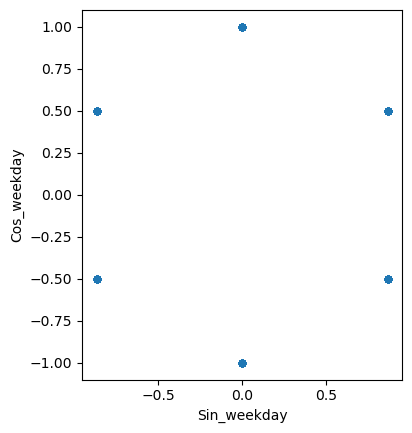

In [41]:
#Check
ax = footfall.plot.scatter('Sin_weekday', 'Cos_weekday').set_aspect('equal')

## Step 4: Find centroids of each location (used in weather data scraping)

Finding area centroids from their geometries:

In [42]:
#Load file with different geographical areas of Bradford
GDF_areas = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\areas.geojson")
GDF_areas.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   centre_name  8 non-null      object  
 1   geometry     8 non-null      geometry
dtypes: geometry(1), object(1)
memory usage: 260.0+ bytes


In [43]:
#Print CRS
print(GDF_areas.crs)

EPSG:4326


In [44]:
GDF_areas['centre_name'].unique()

array(['Bowling Park - BD4 7', 'Wibsey Park - BD6 3',
       'Cliffe Castle Park - BD20 6', 'Lister Park - BD9 4',
       'Bradford BID', 'Met Office - Bradford', 'Bradford - City Centre',
       'Bradford - Penistone Hill'], dtype=object)

Here for all 3 areas (Bradford BID, City Centre and Lister Park), I isolate their corresponding polygon from the 'GDF_areas' dataset, and find the coordinates of their centroid.

In [45]:
#Isolate the Bradford Local Authority area
geo_LA = GDF_areas[GDF_areas['centre_name'] == 'Met Office - Bradford']
#Find centroid in projected coordinates
LA_centroid = geo_LA.geometry.centroid
print(LA_centroid)

5    POINT (-1.85473 53.84471)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_29024\2593751544.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  LA_centroid = geo_LA.geometry.centroid


In [46]:
#Isolate the Bradford BID area
geo_BID = GDF_areas[GDF_areas['centre_name'] == 'Bradford BID']
#Find centroid in projected coordinates
BID_centroid = geo_BID.geometry.centroid
print(BID_centroid)

4    POINT (-1.75189 53.79375)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_29024\3724962223.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  BID_centroid = geo_BID.geometry.centroid


In [47]:
#Isolate the Bradford City Centre area
geo_cc = GDF_areas[GDF_areas['centre_name'] == 'Bradford - City Centre']
#Find centroid in projected coordinates
CC_centroid = geo_cc.geometry.centroid
print(CC_centroid)

6    POINT (-1.75405 53.79221)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_29024\4128320459.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  CC_centroid = geo_cc.geometry.centroid


In [48]:
#Isolate the Lister Park area
geo_Lister = GDF_areas[GDF_areas['centre_name'] == 'Lister Park - BD9 4']
#Find centroid in projected coordinates
Lister_centroid = geo_Lister.geometry.centroid
print(Lister_centroid)

3    POINT (-1.77294 53.81292)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_29024\1188129232.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  Lister_centroid = geo_Lister.geometry.centroid


I scrap the Roberts Park geometry as it was not provided. The green spaces file was dowloaded from the [Ordnance Survey](https://osdatahub.os.uk/data/downloads/open/OpenGreenspace). From the green spaces shapefile, the Roberts Park polygon is collected.

In [49]:
#Load file with different green spaces from Ordnance Survey
Green_spaces = gpd.read_file(r"C:\Users\qxnq723\Desktop\Project 1\DATA\OS Open Greenspace (ESRI Shape File) SE\data\SE_GreenspaceSite.shp")
Green_spaces.head()

,id,function,distName1,distName2,distName3,distName4,geometry
0,3D6C4AE3-840B-80C3-E063-8ECAA00A8EB3,Playing Field,None,None,None,None,"POLYGON Z ((415736.67 432338.02 0, 415750.01 4..."
1,3D6C4AE4-30C4-80C3-E063-8ECAA00A8EB3,Play Space,Hope Park,None,None,None,"POLYGON Z ((415670.18 430406.08 0, 415661.4 43..."
2,3D6C4ACC-1106-80C3-E063-8ECAA00A8EB3,Public Park Or Garden,None,None,None,None,"POLYGON Z ((415812.26 431549.17 0, 415800.98 4..."
3,3D6C4B27-670E-80C3-E063-8ECAA00A8EB3,Religious Grounds,All Saints' Church,None,None,None,"POLYGON Z ((415749.64 432057.02 0, 415712 4320..."
4,3D6C4B27-6C15-80C3-E063-8ECAA00A8EB3,Play Space,None,None,None,None,"POLYGON Z ((415727.72 431565.95 0, 415734.2 43..."


In [50]:
#Search for polygon containing Roberts Park
Green_spaces[Green_spaces['distName1'].str.contains('Roberts Park', na=False, case=False)]

,id,function,distName1,distName2,distName3,distName4,geometry
366,3D6C4B24-2FFB-80C3-E063-8ECAA00A8EB3,Public Park Or Garden,Roberts Park,None,None,None,"POLYGON Z ((413968.48 438278.07 0, 413972.6 43..."


In [51]:
#Isolate that polygon
RobertsPark = Green_spaces[Green_spaces['distName1'] == 'Roberts Park']

In [52]:
#Check CRS
print(RobertsPark.crs)

#Convert the CRS 
RobertsPark = RobertsPark.to_crs(epsg= 4326)

#Check CRS
print(RobertsPark.crs)

EPSG:27700
EPSG:4326


In [53]:
#Find centroid in projected coordinates
Roberts_centroid = RobertsPark.geometry.centroid
print(Lister_centroid)

3    POINT (-1.77294 53.81292)
dtype: geometry


C:\Users\qxnq723\AppData\Local\Temp\ipykernel_29024\2291286420.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  Roberts_centroid = RobertsPark.geometry.centroid


## Step 5: Quick Exploratory Data Analysis

In [54]:
footfall['area'].unique()

array(['BD Walls : Wayfinders', 'Bradford - BID',
       'Bradford - Local Authority', 'BD Walls : Serving the district',
       'BD Walls : The Portal', 'Bradford - City Centre',
       'Bradford - Lister Park', 'Bradford - Roberts Park',
       'Darley Street Market', 'BD Walls : Come on in my friend',
       'BD Walls : Roots'], dtype=object)

<function matplotlib.pyplot.show(close=None, block=None)>

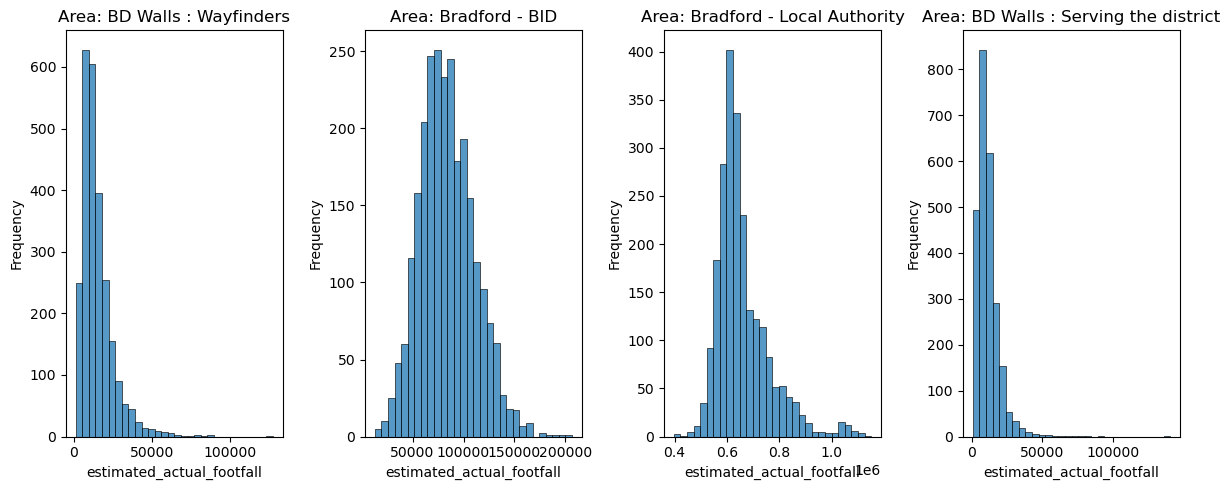

In [55]:
#Plot histograms of footfall counts for all locations

areas = footfall['area'].unique()

fig, axes = plt.subplots(1, 4, figsize=(12, 5))

for ax, area in zip(axes, areas):
    sns.histplot(
        data= footfall[footfall['area']== area],
        x='estimated_actual_footfall',
        bins= 30,
        ax=ax,
    )
    ax.set_title(f'Area: {area}')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show

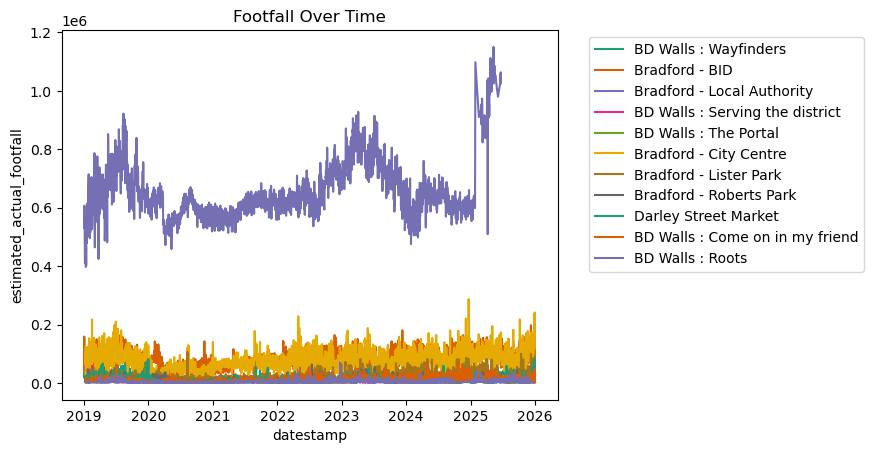

In [56]:
sns.lineplot(data= footfall, 
             x='datestamp', 
             y='estimated_actual_footfall', 
             hue='area', 
             legend='full',
            palette='Dark2')

# add title
plt.title('Footfall Over Time')

# move the legend outside of the main figure
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)

Plot variation over time metrics for a location of interest:

In [57]:
#Choose location of interest
location_of_interest = 'Bradford - BID'
df_LOI = footfall[footfall['area'] == location_of_interest]

In [58]:
timeMetrics = ['weekday','week_of_year', 'month', 'year']
weekday_map= {
    0: 'Mon',
    1: 'Tue',
    2: 'Wed',
    3: 'Thu',
    4: 'Fri',
    5: 'Sat',
    6: 'Sun'
}

Text(0.5, 0.98, 'Summary Plots - Bradford - BID')

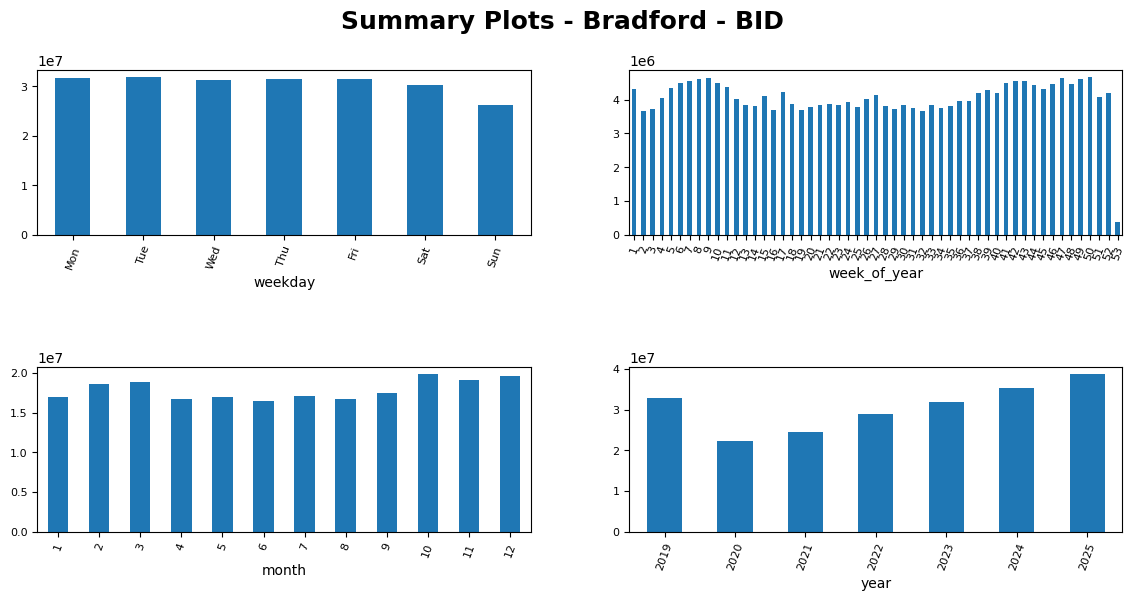

In [59]:
#Create summary plots over weekdays, week of year, months and years for that location

fig, axs = plt.subplots(2, 2, figsize = (14,6))
plt.subplots_adjust(hspace=0.8)    
for i, ax in enumerate(axs.flat):
    metric = timeMetrics[i]
    if metric == 'weekday':
        weekday_series= (
            df_LOI.groupby(['weekday'])['estimated_actual_footfall']
            .sum()
            .rename(index= weekday_map)
            .reindex(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']))
        weekday_series.plot.bar(ax=ax, rot=70, fontsize = 8) 
    else:
        df_LOI.groupby(metric)['estimated_actual_footfall'].sum().plot.bar(ax=ax, rot=70, fontsize = 8)
fig.suptitle(f'Summary Plots - {location_of_interest}', fontsize= 18, weight='bold') 

## Step 6: Saving the clean data for next steps

In [60]:
footfall.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27186 entries, 0 to 32097
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   datestamp                  27186 non-null  datetime64[ns]
 1   area                       27186 non-null  object        
 2   estimated_actual_footfall  27186 non-null  float64       
 3   year                       27186 non-null  int32         
 4   month                      27186 non-null  int32         
 5   monthday                   27186 non-null  int32         
 6   weekday                    27186 non-null  int32         
 7   week_of_year               27186 non-null  UInt32        
 8   Sin_weekday                27186 non-null  float64       
 9   Cos_weekday                27186 non-null  float64       
 10  Sin_monthday               27186 non-null  float64       
 11  Cos_monthday               27186 non-null  float64       
 12  Sin_week_

In [61]:
#Drop columns unneeded for analysis
footfall = footfall.drop(columns=['monthday'])
footfall.head()

,datestamp,area,estimated_actual_footfall,year,month,weekday,week_of_year,Sin_weekday,Cos_weekday,Sin_monthday,Cos_monthday,Sin_week_of_year,Cos_week_of_year,Sin_month,Cos_month
0,2019-01-01,BD Walls : Wayfinders,79795.860,2019,1,1,1,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
1,2019-01-01,Bradford - BID,54153.485,2019,1,1,1,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
2,2019-01-01,Bradford - Local Authority,530996.000,2019,1,1,1,0.866025,0.5,0.201299,0.979530,0.118273,0.992981,0.5,0.866025
3,2019-01-02,BD Walls : Wayfinders,17168.990,2019,1,2,1,0.866025,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025
4,2019-01-02,Bradford - BID,158891.385,2019,1,2,1,0.866025,-0.5,0.394356,0.918958,0.118273,0.992981,0.5,0.866025


In [62]:
#Save the cleaned dataset
footfall.to_csv('footfall_Mix_Clean.csv')